# Sentinel-1 TIFF Folder Explorer

Point `DATA_DIR` at a directory to:

1. Build an inventory table of every readable raster
2. Plot a quicklook of each TIFF 
3. Plot the histogram for each band


In [7]:
from pathlib import Path

# --- point this at your folder
#DATA_DIR = Path('/oscar/data/deeps/private/chorvat/Summer_UTRA_Vincent/Sentinel-1_SAR_prossesed_tiffs')
DATA_DIR = Path('/oscar/home/vxlee/Summer_UTRA/sample')

GLOB_PATTERN = '*.tif'

# Where to save figures 
#FIG_DIR = Path('figures') / '/oscar/data/deeps/private/chorvat/Summer_UTRA_Vincent/Sentinel-1_SAR_prossesed_tiffs/figures'
FIG_DIR = Path('figures') / '/oscar/home/vxlee/Summer_UTRA/Results'
SAVE_FIGURES = True

# Read rasters 
MAX_RASTER_PIXELS = 1_500_000

# Cap how many scenes get quicklooks / histograms. None = every file.
MAX_SCENES_TO_PLOT = 12

# Convert linear power to decibels for display Gamma0 backscatter is usually viewed in dB. Set False for products that are already in physical/dB units.
CONVERT_TO_DB = True

# Percentiles used for color stretch and reported stats.
STRETCH_PCTS = (2, 98)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent

ROOT = Path('.').resolve()
DATA_DIR = (ROOT / DATA_DIR).resolve() if not DATA_DIR.is_absolute() else DATA_DIR
FIG_DIR = (ROOT / FIG_DIR).resolve() if not FIG_DIR.is_absolute() else FIG_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Inspecting: {DATA_DIR}')
print(f'Pattern   : {GLOB_PATTERN}')
assert DATA_DIR.exists(), f'DATA_DIR does not exist: {DATA_DIR}'

Inspecting: /oscar/home/vxlee/Summer_UTRA/sample
Pattern   : *.tif


In [9]:
def to_display(linear):
    """Optionally convert linear power to dB; otherwise pass values through."""
    arr = np.asarray(linear, dtype='float32')
    if not CONVERT_TO_DB:
        out = arr.copy()
        if np.ma.isMaskedArray(linear):
            out[np.ma.getmaskarray(linear)] = np.nan
        return out
    out = np.full(arr.shape, np.nan, dtype='float32')
    good = np.isfinite(arr) & (arr > 0)
    out[good] = 10.0 * np.log10(arr[good])
    return out


UNIT = 'dB' if CONVERT_TO_DB else 'value'


def finite_values(arr):
    vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
    return vals[np.isfinite(vals)]


def finite_percentiles(arr, percentiles):
    vals = finite_values(arr)
    if vals.size == 0:
        return [np.nan] * len(percentiles)
    return np.nanpercentile(vals, percentiles)


def read_downsampled(src, band_index, max_pixels=MAX_RASTER_PIXELS):
    scale = max(1, int(np.ceil(np.sqrt((src.width * src.height) / max_pixels))))
    out_h = max(1, src.height // scale)
    out_w = max(1, src.width // scale)
    return src.read(band_index, out_shape=(out_h, out_w),
                    resampling=Resampling.average, masked=True)


def band_label(src, band):
    return src.descriptions[band - 1] or f'band{band}'


def savefig(fig, name):
    if SAVE_FIGURES:
        out = FIG_DIR / name
        fig.savefig(out, dpi=180, bbox_inches='tight')
        print(f'saved {out}')

In [10]:
files = sorted(DATA_DIR.glob(GLOB_PATTERN))
rows = []
for path in files:
    try:
        with rasterio.open(path) as src:
            rows.append({
                'path': path,
                'name': path.name,
                'bands': src.count,
                'band_names': ','.join(band_label(src, i + 1) for i in range(src.count)),
                'dtype': src.dtypes[0],
                'crs': str(src.crs),
                'width': src.width,
                'height': src.height,
                'res_x': src.res[0],
                'res_y': src.res[1],
                'left': src.bounds.left,
                'right': src.bounds.right,
                'bottom': src.bounds.bottom,
                'top': src.bounds.top,
                'size_gb': path.stat().st_size / 1e9,
            })
    except Exception as exc:
        rows.append({'path': path, 'name': path.name, 'error': str(exc)})

inv = pd.DataFrame(rows).reset_index(drop=True)
print(f'Readable rasters: {len(inv):,}')
if 'error' in inv.columns:
    bad = inv[inv['error'].notna()] if 'error' in inv else inv
    if len(bad):
        print(f'Unreadable files: {len(bad)}')
display(inv.drop(columns=['path']))

Readable rasters: 1


,name,bands,band_names,dtype,crs,width,height,res_x,res_y,left,right,bottom,top,size_gb
0,S1A_EW_GRDM_1SDH_20211216T081933_20211216T0820...,2,"HH,HV",float32,EPSG:3031,12633,11728,40.0,40.0,-2395634.354,-1890314.354,597388.708086,1.066509e+06,0.489149


## Per-band Statistics

Finite-pixel fraction and value percentiles per band. Useful for spotting empty bands or broken calibration before plotting.

In [11]:
readable = inv[inv.get('crs').notna()] if 'crs' in inv else inv
stats = []
for path in readable['path'].tolist():
    with rasterio.open(path) as src:
        for band in range(1, src.count + 1):
            arr = to_display(read_downsampled(src, band))
            p_lo, p50, p_hi = finite_percentiles(arr, [STRETCH_PCTS[0], 50, STRETCH_PCTS[1]])
            stats.append({
                'name': path.name,
                'band': band,
                'label': band_label(src, band),
                'finite_fraction': np.isfinite(arr).mean(),
                f'p{STRETCH_PCTS[0]:02d}': p_lo,
                'p50': p50,
                f'p{STRETCH_PCTS[1]:02d}': p_hi,
            })

band_stats = pd.DataFrame(stats)
display(band_stats)

,name,band,label,finite_fraction,p02,p50,p98
0,S1A_EW_GRDM_1SDH_20211216T081933_20211216T0820...,1,HH,0.473080,-21.148361,-13.610537,2.344127
1,S1A_EW_GRDM_1SDH_20211216T081933_20211216T0820...,2,HV,0.473013,-34.518221,-22.143410,-3.886985


## Quicklook Panels

One row of panels per scene (one panel per band), read at reduced resolution and stretched to the configured percentiles.

Plotting first 1 of 1 scenes (raise MAX_SCENES_TO_PLOT for more).


saved /oscar/home/vxlee/Summer_UTRA/Results/S1A_EW_GRDM_1SDH_20211216T081933_20211216T082016_041031_04DFC5_7DD5_Gamma0_TC_3031_quicklook.png


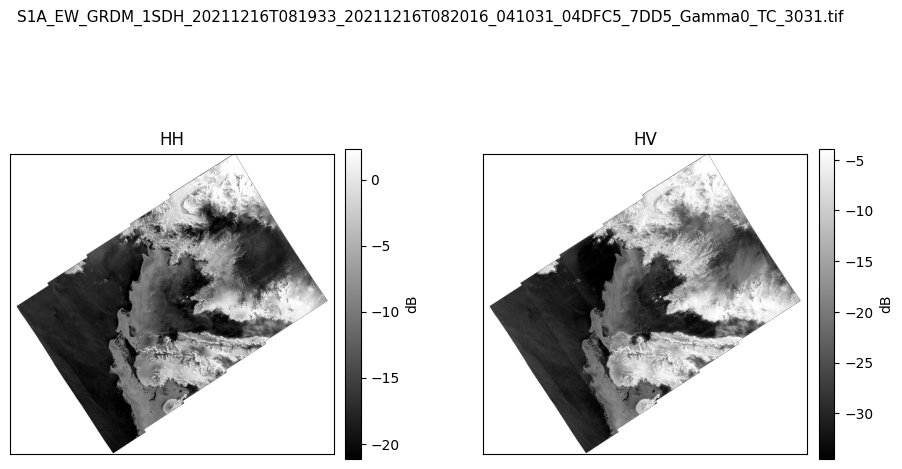

In [12]:
def plot_scene(path):
    with rasterio.open(path) as src:
        extent = plotting_extent(src)
        labels = [band_label(src, i + 1) for i in range(src.count)]
        arrays = [to_display(read_downsampled(src, i)) for i in range(1, src.count + 1)]

    n = len(arrays)
    fig, axes = plt.subplots(1, n, figsize=(5.6 * n, 5.6), squeeze=False)
    for ax, title, arr in zip(axes[0], labels, arrays):
        vmin, vmax = finite_percentiles(arr, list(STRETCH_PCTS))
        im = ax.imshow(arr, origin='upper', extent=extent, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, shrink=0.72, pad=0.03, label=UNIT)
    fig.suptitle(path.name, y=1.02, fontsize=11)
    savefig(fig, path.stem + '_quicklook.png')
    plt.show()


plot_paths = readable['path'].tolist()
if MAX_SCENES_TO_PLOT is not None:
    plot_paths = plot_paths[:MAX_SCENES_TO_PLOT]
    print(f'Plotting first {len(plot_paths)} of {len(readable)} scenes '
          f'(raise MAX_SCENES_TO_PLOT for more).')

for path in plot_paths:
    plot_scene(path)

## Pixel-value Distributions

Overlaid histograms across the plotted scenes, one subplot per band index. Makes it easy to compare dynamic ranges and spot outlier scenes.

saved /oscar/home/vxlee/Summer_UTRA/Results/folder_histograms.png


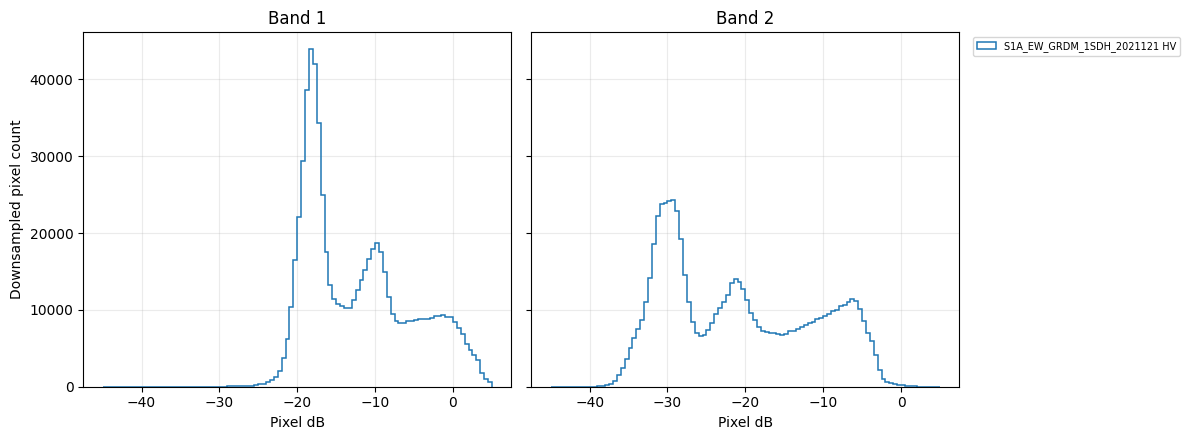

In [13]:
# Figure out the max band count among the scenes we're plotting.
max_bands = 1
for path in plot_paths:
    with rasterio.open(path) as src:
        max_bands = max(max_bands, src.count)

# Auto-range from the data if not converting to dB; use a sensible dB window otherwise.
if CONVERT_TO_DB:
    hist_range = (-45, 5)
else:
    all_vals = []
    for path in plot_paths:
        with rasterio.open(path) as src:
            for band in range(1, src.count + 1):
                all_vals.append(finite_percentiles(to_display(read_downsampled(src, band)),
                                                    [1, 99]))
    all_vals = np.array(all_vals)
    hist_range = (np.nanmin(all_vals[:, 0]), np.nanmax(all_vals[:, 1]))

fig, axes = plt.subplots(1, max_bands, figsize=(6 * max_bands, 4.5),
                         sharey=True, squeeze=False)
axes = axes[0]
for path in plot_paths:
    with rasterio.open(path) as src:
        for band in range(1, src.count + 1):
            vals = finite_values(to_display(read_downsampled(src, band)))
            if vals.size:
                axes[band - 1].hist(vals, bins=100, range=hist_range, histtype='step',
                                    linewidth=1.1, label=f'{path.stem[:24]} {band_label(src, band)}')

for i, ax in enumerate(axes, start=1):
    ax.set_title(f'Band {i}')
    ax.set_xlabel(f'Pixel {UNIT}')
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Downsampled pixel count')
axes[-1].legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
savefig(fig, 'folder_histograms.png')
plt.show()

## Land Masking

Generate a land mask for each scene/band and remove land pixels *before* they reach any thresholding or segmentation step. If `LAND_MASK_PATH` is set to a real land/water dataset (a shapefile of land polygons or a pre-made land raster) it is rasterized/aligned to each scene's grid; otherwise a texture-based heuristic (land is typically rougher -- higher local backscatter variance -- than open water or sea ice) is used as an approximate fallback. Results are stored in `land_masks` (keyed by scene path, one boolean mask per band) and consumed by every algorithm below.


In [ ]:
from scipy.ndimage import uniform_filter

# Optional: point this at a real land/water dataset -- a coastline/land-polygon shapefile or
# a pre-made land raster aligned to your scenes -- to build an exact land mask. Leave as None
# to fall back to the texture-based heuristic below.
LAND_MASK_PATH = None  # e.g. Path('/path/to/land_polygons.shp') or Path('/path/to/land_mask.tif')

# Heuristic fallback: land surfaces (rock, vegetation, urban) are typically much rougher --
# higher local backscatter variance -- than open water or sea ice, so pixels with unusually
# high local standard deviation are flagged as land. This is a coarse approximation; supply
# LAND_MASK_PATH with a real land/water dataset for production use.
LAND_TEXTURE_WINDOW = 15
LAND_STD_PERCENTILE = 90  # pixels with local std above this per-scene percentile -> land


def local_std(arr, window=LAND_TEXTURE_WINDOW):
    """Local standard deviation via the 'mean of squares minus square of mean' identity."""
    valid = np.isfinite(arr)
    fill_value = np.nanmean(arr[valid]) if valid.any() else 0.0
    filled = np.where(valid, arr, fill_value).astype('float32')
    mean = uniform_filter(filled, size=window)
    mean_sq = uniform_filter(filled ** 2, size=window)
    return np.sqrt(np.clip(mean_sq - mean ** 2, 0, None))


def heuristic_land_mask(arr, window=LAND_TEXTURE_WINDOW, percentile=LAND_STD_PERCENTILE):
    """Flag likely-land pixels as those with unusually high local texture (backscatter std)."""
    valid = np.isfinite(arr)
    if not valid.any():
        return np.zeros(arr.shape, dtype=bool)
    std = local_std(arr, window=window)
    thresh = np.nanpercentile(std[valid], percentile)
    land = std > thresh
    land[~valid] = False
    return land


def rasterized_land_mask(src, shape):
    """Rasterize/read an external land mask aligned to `src`'s grid, or None if unconfigured."""
    if LAND_MASK_PATH is None:
        return None
    if LAND_MASK_PATH.suffix.lower() in ('.tif', '.tiff'):
        with rasterio.open(LAND_MASK_PATH) as land_src:
            land = land_src.read(1, out_shape=shape, resampling=Resampling.nearest)
        return land.astype(bool)
    import geopandas as gpd
    from rasterio.features import rasterize
    gdf = gpd.read_file(LAND_MASK_PATH).to_crs(src.crs)
    return rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=shape, transform=src.transform, fill=0, dtype='uint8',
    ).astype(bool)


def get_land_mask(src, arr):
    """Boolean land mask for one band array: uses LAND_MASK_PATH if configured, otherwise the
    local-texture heuristic."""
    mask = rasterized_land_mask(src, arr.shape)
    if mask is None:
        mask = heuristic_land_mask(arr)
    return mask


land_masks = {}  # path -> list of per-band boolean land masks (True = land, to be excluded)
for path in plot_paths:
    with rasterio.open(path) as src:
        arrays = [to_display(read_downsampled(src, i)) for i in range(1, src.count + 1)]
        land_masks[path] = [get_land_mask(src, arr) for arr in arrays]

all_land_fracs = [m.mean() for masks in land_masks.values() for m in masks]
avg_land_pct = (np.mean(all_land_fracs) * 100) if all_land_fracs else 0.0
print(f'Computed land masks for {len(land_masks)} scene(s) '
      f'(avg. {avg_land_pct:.1f}% of pixels flagged as land).')


## Binary Segmentation: Local, Otsu, and K-Means

Three independent ways of turning each SAR band into a binary ice/water mask: a locally-adaptive threshold, a global Otsu threshold, and a 2-cluster k-means classification. Each produces its own `mask_results_*` list (path, name, extent, band labels, and masks) so the methods can be compared directly, including after morphological filtering, further down.


In [ ]:
from scipy.ndimage import uniform_filter

# Window size scales with image size instead of being fixed: expressed as a fraction of
# the smaller image dimension, then clamped to a sane range and forced odd (symmetric
# neighborhood). This keeps the local neighborhood proportionate whether the scene is a
# small chip or a full-size Sentinel product.
ADAPTIVE_WINDOW_FRACTION = 0.02   # ~2% of the smaller image dimension
ADAPTIVE_WINDOW_MIN = 15          # never go below this many pixels
ADAPTIVE_WINDOW_MAX = 201         # never go above this many pixels

# Subtracted from the local mean before comparing; raise to make the mask stricter (fewer
# foreground pixels), lower (or make negative) to make it more permissive.
ADAPTIVE_OFFSET = 0.0


def compute_adaptive_window(shape, fraction=ADAPTIVE_WINDOW_FRACTION,
                             min_window=ADAPTIVE_WINDOW_MIN, max_window=ADAPTIVE_WINDOW_MAX):
    """Pick a local-threshold window size proportional to the image's smaller dimension,
    clamped to [min_window, max_window] and rounded up to the nearest odd number."""
    window = int(round(fraction * min(shape)))
    window = max(min_window, min(max_window, window))
    if window % 2 == 0:
        window += 1
    return window


def adaptive_threshold_mask(arr, window=None, offset=ADAPTIVE_OFFSET):
    """Locally-adaptive threshold -> binary mask.

    A pixel is foreground (True) if it exceeds the mean of its local neighborhood minus
    `offset`. NaN/masked pixels (nodata, or land -- see the Land Masking cell above) are
    filled with the scene mean before filtering and forced to False (background) in the
    returned mask. If `window` is not given, it is derived from the array's own size via
    `compute_adaptive_window`.
    """
    if window is None:
        window = compute_adaptive_window(arr.shape)
    valid = np.isfinite(arr)
    fill_value = np.nanmean(arr[valid]) if valid.any() else 0.0
    filled = np.where(valid, arr, fill_value).astype('float32')
    local_mean = uniform_filter(filled, size=window)
    mask = filled > (local_mean - offset)
    mask[~valid] = False
    return mask


mask_results_local = []  # one entry per scene: path, name, extent, band labels, and masks
for path in plot_paths:
    with rasterio.open(path) as src:
        extent = plotting_extent(src)
        labels_bands = [band_label(src, i + 1) for i in range(src.count)]
        arrays = [to_display(read_downsampled(src, i)) for i in range(1, src.count + 1)]
    masks = []
    for arr, land in zip(arrays, land_masks[path]):
        arr_no_land = np.where(land, np.nan, arr)  # remove land before thresholding
        m = adaptive_threshold_mask(arr_no_land)   # window auto-sized per array
        m[land] = False                            # land is never classified as ice/water
        masks.append(m)
    mask_results_local.append({
        'path': path,
        'name': path.name,
        'extent': extent,
        'labels': labels_bands,
        'masks': masks,
    })

print(f'Computed local-threshold masks for {len(mask_results_local)} scene(s) '
      f'(window size adapted per image; land excluded).')


In [ ]:
def otsu_threshold(vals, bins=256):
    """Classic Otsu's method: return the scalar threshold that maximizes between-class
    variance over a 1-D array of finite values."""
    hist, bin_edges = np.histogram(vals, bins=bins)
    hist = hist.astype('float64')
    bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    weight_bg = np.cumsum(hist)
    weight_fg = np.cumsum(hist[::-1])[::-1]

    sum_bg = np.cumsum(hist * bin_mids)
    sum_fg = np.cumsum((hist * bin_mids)[::-1])[::-1]

    mean_bg = np.divide(sum_bg, weight_bg, out=np.zeros_like(sum_bg), where=weight_bg > 0)
    mean_fg = np.divide(sum_fg, weight_fg, out=np.zeros_like(sum_fg), where=weight_fg > 0)

    between_class_var = weight_bg[:-1] * weight_fg[1:] * (mean_bg[:-1] - mean_fg[1:]) ** 2
    best_idx = np.argmax(between_class_var)
    return bin_mids[best_idx]


def otsu_threshold_mask(arr):
    """Global Otsu threshold -> binary mask. NaN/masked (nodata, or land) pixels are forced
    to False."""
    valid = np.isfinite(arr)
    vals = arr[valid]
    if vals.size == 0:
        return np.zeros_like(arr, dtype=bool)
    thresh = otsu_threshold(vals)
    mask = arr > thresh
    mask[~valid] = False
    return mask


mask_results_otsu = []  # one entry per scene: path, name, extent, band labels, and masks
for path in plot_paths:
    with rasterio.open(path) as src:
        extent = plotting_extent(src)
        labels_bands = [band_label(src, i + 1) for i in range(src.count)]
        arrays = [to_display(read_downsampled(src, i)) for i in range(1, src.count + 1)]
    masks = []
    for arr, land in zip(arrays, land_masks[path]):
        arr_no_land = np.where(land, np.nan, arr)  # remove land before thresholding
        m = otsu_threshold_mask(arr_no_land)
        m[land] = False                            # land is never classified as ice/water
        masks.append(m)
    mask_results_otsu.append({
        'path': path,
        'name': path.name,
        'extent': extent,
        'labels': labels_bands,
        'masks': masks,
    })

print(f'Computed Otsu-threshold masks for {len(mask_results_otsu)} scene(s) (land excluded).')


## K-Means Clustering (Ice vs. Sea Water)

Cluster each band's pixel values into two groups (k=2) with a simple 1-D k-means. The cluster with the higher mean backscatter is labeled **ice**, the lower-backscatter cluster is labeled **sea water**. Results are stored in `mask_results_kmeans`.


In [ ]:
# --- K-means (k=2) clustering: classify each pixel as ice (bright cluster) or sea water
# (dark cluster). Implemented from scratch (Lloyd's algorithm) to avoid an extra dependency.
KMEANS_K = 2
KMEANS_ITERS = 50
KMEANS_SEED = 0


def kmeans_1d(vals, k=KMEANS_K, n_iter=KMEANS_ITERS, seed=KMEANS_SEED):
    """1-D k-means: cluster a 1-D array of pixel values into `k` groups.
    Returns (cluster_labels, cluster_centers)."""
    rng = np.random.default_rng(seed)
    if vals.size < k:
        fallback = vals.mean() if vals.size else 0.0
        return np.zeros(vals.shape, dtype=int), np.full(k, fallback)
    centers = rng.choice(vals, size=k, replace=False).astype('float64')
    for _ in range(n_iter):
        dist = np.abs(vals[:, None] - centers[None, :])
        cluster_labels = np.argmin(dist, axis=1)
        new_centers = np.array([
            vals[cluster_labels == i].mean() if np.any(cluster_labels == i) else centers[i]
            for i in range(k)
        ])
        if np.allclose(new_centers, centers):
            centers = new_centers
            break
        centers = new_centers
    return cluster_labels, centers


def kmeans_ice_mask(arr, k=KMEANS_K, n_iter=KMEANS_ITERS, seed=KMEANS_SEED):
    """K-means (k=2) classification -> binary mask. The cluster with the higher mean
    backscatter is labeled ice (True); the lower-backscatter cluster is sea water (False).
    NaN/masked (nodata, or land) pixels are forced to False."""
    valid = np.isfinite(arr)
    vals = arr[valid]
    mask = np.zeros(arr.shape, dtype=bool)
    if vals.size == 0:
        return mask
    cluster_labels, centers = kmeans_1d(vals, k=k, n_iter=n_iter, seed=seed)
    ice_cluster = int(np.argmax(centers))
    mask[valid] = (cluster_labels == ice_cluster)
    return mask


mask_results_kmeans = []  # one entry per scene: path, name, extent, band labels, and masks
for path in plot_paths:
    with rasterio.open(path) as src:
        extent = plotting_extent(src)
        labels_bands = [band_label(src, i + 1) for i in range(src.count)]
        arrays = [to_display(read_downsampled(src, i)) for i in range(1, src.count + 1)]
    masks = []
    for arr, land in zip(arrays, land_masks[path]):
        arr_no_land = np.where(land, np.nan, arr)  # remove land before clustering
        m = kmeans_ice_mask(arr_no_land)
        m[land] = False                            # land is never classified as ice/water
        masks.append(m)
    mask_results_kmeans.append({
        'path': path,
        'name': path.name,
        'extent': extent,
        'labels': labels_bands,
        'masks': masks,
    })

print(f'Computed K-means ice/water masks for {len(mask_results_kmeans)} scene(s) (land excluded).')


## Morphological Refinement (Opening → Closing)

Apply the same morphological opening-then-closing filter to **all three** candidate segmentations (local, Otsu, and K-means), using a simple, predefined structuring element (kernel). Each filtered result gets its own `mask_results_*_morph` list, and each is saved to `FIG_DIR` separately (`..._mask_local_morph.png`, `..._mask_otsu_morph.png`, `..._mask_kmeans_morph.png`) so the pre- and post-filter results can be compared for every method.


In [ ]:
from scipy.ndimage import binary_opening, binary_closing, generate_binary_structure

# Simple, predefined structuring element (kernel): a 3x3, 4-connected cross. Swap for
# np.ones((3, 3), dtype=bool) for an 8-connected 3x3 square kernel instead.
MORPH_STRUCTURE = generate_binary_structure(2, 1)


def morphological_refine(mask, structure=MORPH_STRUCTURE):
    """Morphologically clean up a *candidate* ice/water segmentation mask.

    Only meant to run on candidate segmentation regions (e.g. the local/Otsu/K-means output
    above): sliding a small structuring element (kernel) across the mask and deciding, per
    neighborhood, whether to erode or dilate may distort otherwise-valid edges elsewhere in
    the scene, so it should not be applied wholesale.

    Targets two specific candidate-region artifacts:
      (a) Concave notches along a boundary that should be convex (ice regions are expected to
          be roughly convex) -- fixed by closing, which fills small dark concavities.
      (b) Short, spurious boundaries/speckles between large ice regions -- fixed by opening,
          which erases isolated specks without shrinking the main regions.

    Using the structuring element as a sliding window:
      - Erosion:  a pixel only survives as foreground if every pixel under the kernel is
                  foreground -- a single dark (background) pixel under the kernel shaves the
                  boundary there, erasing isolated specks.
      - Dilation: a pixel becomes foreground if any pixel under the kernel is foreground -- a
                  single bright pixel under the kernel expands the boundary, bridging gaps.
      - Opening (erosion, then dilation): removes small bright specks / short spurious
                  boundaries while preserving the size of large regions.
      - Closing (dilation, then erosion): fills small dark gaps and concave notches,
                  restoring the convex boundary expected of ice regions.
    """
    opened = binary_opening(mask, structure=structure)
    closed = binary_closing(opened, structure=structure)
    return closed


def refine_mask_results(results):
    """Apply morphological_refine to every band mask in a mask_results_* list, returning a new
    list with the same path/name/extent/labels but filtered masks."""
    refined = []
    for entry in results:
        refined.append({
            'path': entry['path'],
            'name': entry['name'],
            'extent': entry['extent'],
            'labels': entry['labels'],
            'masks': [morphological_refine(m) for m in entry['masks']],
        })
    return refined


def plot_scene_masks(entry, algorithm):
    """Plot one panel per band for a scene and save it to FIG_DIR, tagged with `algorithm`."""
    n = len(entry['masks'])
    fig, axes = plt.subplots(1, n, figsize=(5.6 * n, 5.6), squeeze=False)
    for ax, title, mask in zip(axes[0], entry['labels'], entry['masks']):
        ax.imshow(mask, origin='upper', extent=entry['extent'], cmap='gray', vmin=0, vmax=1)
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{entry['name']} — {algorithm} threshold mask", y=1.02, fontsize=11)
    # Save under FIG_DIR with a name tagged by algorithm, so every method's output is separate.
    savefig(fig, f"{entry['path'].stem}_mask_{algorithm}.png")
    plt.show()


mask_results_local_morph = refine_mask_results(mask_results_local)
mask_results_otsu_morph = refine_mask_results(mask_results_otsu)
mask_results_kmeans_morph = refine_mask_results(mask_results_kmeans)

print(f'Filtered {len(mask_results_local_morph)} local, {len(mask_results_otsu_morph)} Otsu, '
      f'and {len(mask_results_kmeans_morph)} K-means scene(s) with opening → closing.')

# Save each filtered result separately in FIG_DIR, distinct from its unfiltered counterpart.
for entry in mask_results_local_morph:
    plot_scene_masks(entry, 'local_morph')
for entry in mask_results_otsu_morph:
    plot_scene_masks(entry, 'otsu_morph')
for entry in mask_results_kmeans_morph:
    plot_scene_masks(entry, 'kmeans_morph')


## Quicklook Preview: Local vs. Otsu vs. K-Means, Before and After Filtering

Same one-row-per-scene, one-panel-per-band layout as the imagery Quicklook Panels above, now run across all six mask variants for direct comparison, in this order: local thresholding, local thresholding after filtering, Otsu method, Otsu method after filtering, K-means clusters, and K-means clusters after filtering. Each is saved to `FIG_DIR` under its own algorithm-tagged filename.


In [ ]:
# plot_scene_masks() was defined above in the Morphological Refinement cell; reused here.
quicklook_comparisons = [
    ('local', mask_results_local),
    ('local_morph', mask_results_local_morph),
    ('otsu', mask_results_otsu),
    ('otsu_morph', mask_results_otsu_morph),
    ('kmeans', mask_results_kmeans),
    ('kmeans_morph', mask_results_kmeans_morph),
]

for algorithm, results in quicklook_comparisons:
    for entry in results:
        plot_scene_masks(entry, algorithm)


## Watershed Segmentation

Separate touching/merged ice regions within a candidate binary mask using watershed segmentation: the distance transform of the mask is treated as a topographic surface, local peaks become region "seeds", and flooding outward from each seed splits merged regions at the ridge lines between them. Applied here to the morphologically-filtered K-means mask (`mask_results_kmeans_morph`), since that is the cleanest candidate segmentation. Each scene's result is saved to `FIG_DIR` as `..._mask_watershed.png`.


In [ ]:
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

# Minimum allowed distance (pixels) between separated region seeds/peaks. Raise this to merge
# nearby peaks into one region (less splitting); lower it to split more aggressively.
WATERSHED_MIN_DISTANCE = 10


def watershed_segment(mask, min_distance=WATERSHED_MIN_DISTANCE):
    """Watershed segmentation to separate touching regions within a binary mask.

    1. Compute the distance transform of the mask (each foreground pixel's distance to the
       nearest background pixel).
    2. Treat local maxima of that distance transform as region "seeds" (markers) -- these sit
       at the core of each blob.
    3. Flood outward from each seed along the inverted distance transform (so flooding climbs
       downhill from each peak), splitting merged blobs at the ridge lines between them.

    Returns an integer label image (0 = background, 1..N = separated regions).
    """
    if not mask.any():
        return np.zeros(mask.shape, dtype=int)
    distance = ndi.distance_transform_edt(mask)
    coords = peak_local_max(distance, min_distance=min_distance, labels=mask)
    marker_mask = np.zeros(distance.shape, dtype=bool)
    marker_mask[tuple(coords.T)] = True
    markers, _ = ndi.label(marker_mask)
    return watershed(-distance, markers, mask=mask)


mask_results_watershed = []  # one entry per scene: path, name, extent, band labels, and segments
for entry in mask_results_kmeans_morph:
    segments = [watershed_segment(m) for m in entry['masks']]
    mask_results_watershed.append({
        'path': entry['path'],
        'name': entry['name'],
        'extent': entry['extent'],
        'labels': entry['labels'],
        'segments': segments,
    })

print(f'Computed watershed segmentation for {len(mask_results_watershed)} scene(s).')


def plot_scene_watershed(entry, algorithm='watershed'):
    """Plot one panel per band of labeled watershed segments and save it to FIG_DIR."""
    n = len(entry['segments'])
    fig, axes = plt.subplots(1, n, figsize=(5.6 * n, 5.6), squeeze=False)
    for ax, title, seg in zip(axes[0], entry['labels'], entry['segments']):
        ax.imshow(seg, origin='upper', extent=entry['extent'], cmap='nipy_spectral')
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{entry['name']} — {algorithm} segmentation", y=1.02, fontsize=11)
    savefig(fig, f"{entry['path'].stem}_mask_{algorithm}.png")
    plt.show()


for entry in mask_results_watershed:
    plot_scene_watershed(entry)
